<h2>Importing Libraries</h2>

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score

In [44]:
%matplotlib inline

In [45]:
train = pd.read_csv("trainheart.csv")
test = pd.read_csv("testh.csv")

In [46]:
print(train.head())
print(train.shape)
print(train.info())
print(train.describe())
print(train.isnull().sum())

   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1   
3     150                0            1.0            2   
4     125                1            3.8            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2         7      Presence  
1                        0         3       Absence  
2    

<b><p>Age distribution</p></b>

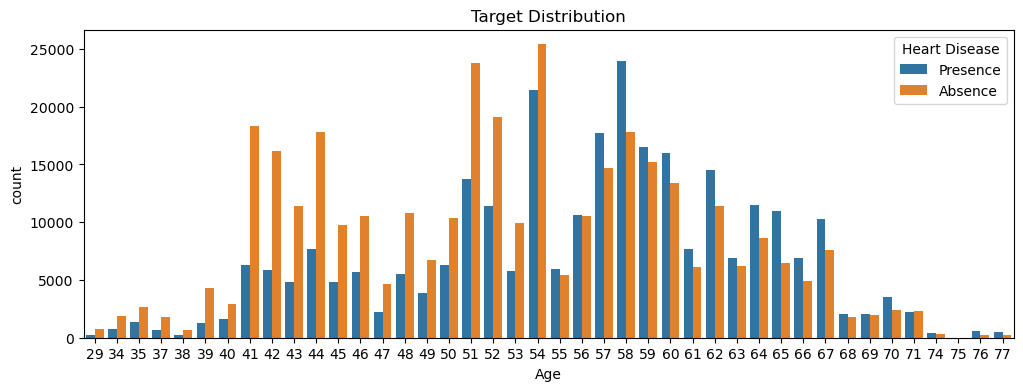

In [47]:
plt.figure(figsize=(12,4))
sns.countplot(x='Age', data=train, hue = 'Heart Disease' )
plt.title('Target Distribution')
plt.show()

In [48]:
train['Heart Disease'] = train['Heart Disease'].map({
    'Presence': 1,
    'Absence': 0
}) #encoding the disease factor

In [49]:
X = train.drop('Heart Disease', axis = 1)
Y = train['Heart Disease']

In [50]:
Y

0         1
1         0
2         0
3         0
4         1
         ..
629995    0
629996    0
629997    1
629998    1
629999    0
Name: Heart Disease, Length: 630000, dtype: int64

In [51]:
X

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6


In [52]:
print(X.dtypes)

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object


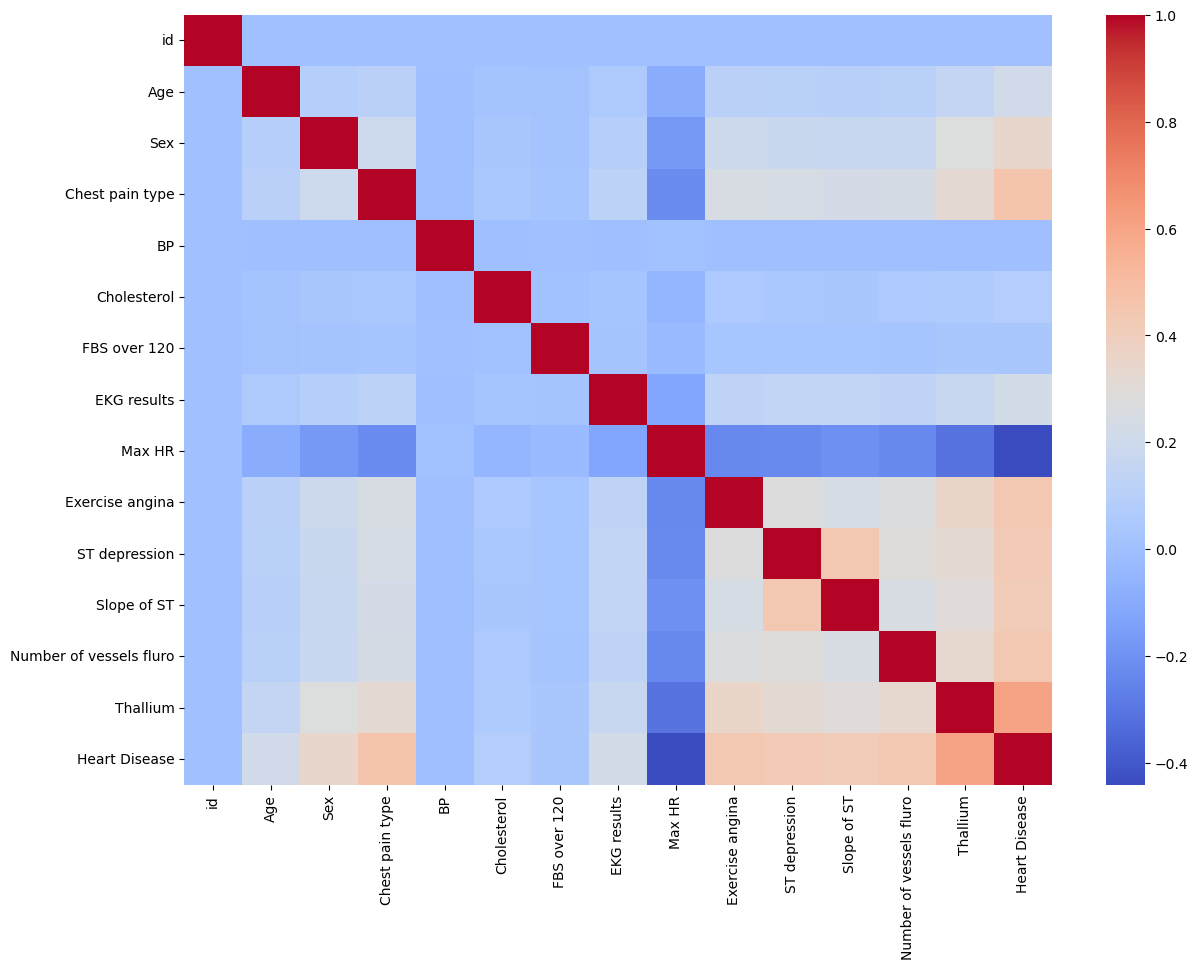

In [53]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [54]:
corr_target = corr['Heart Disease'].sort_values(ascending=False)

print(corr_target)

Heart Disease              1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
id                         0.000209
BP                        -0.005181
Max HR                    -0.440985
Name: Heart Disease, dtype: float64


<h5>id and BP have the least correlation</h5>

In [55]:
X = X.drop('id', axis=1)
test_ids = test['id']
test = test.drop('id', axis=1)

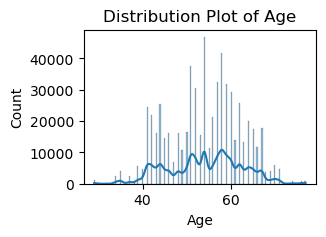

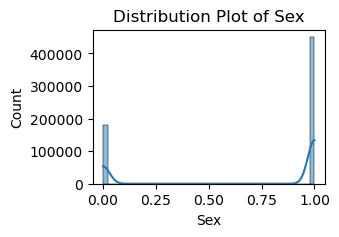

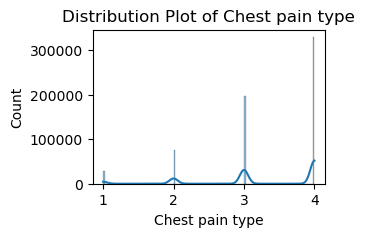

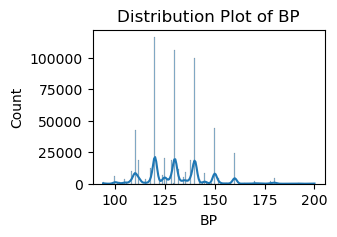

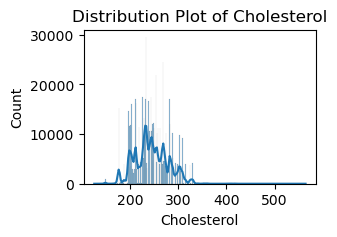

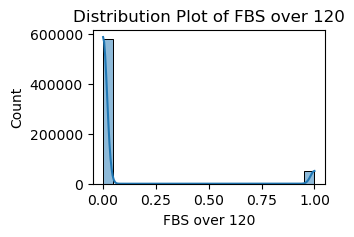

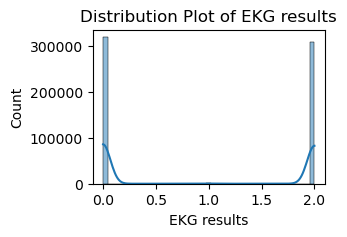

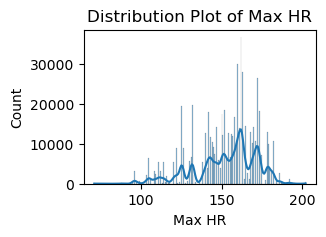

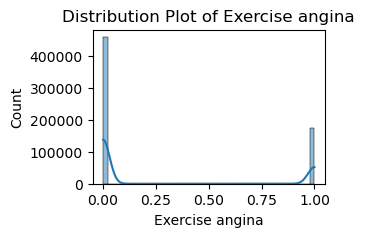

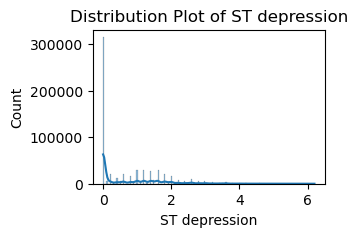

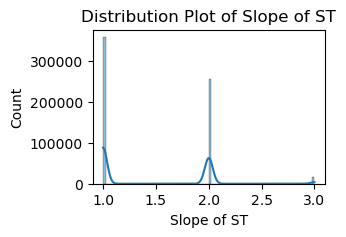

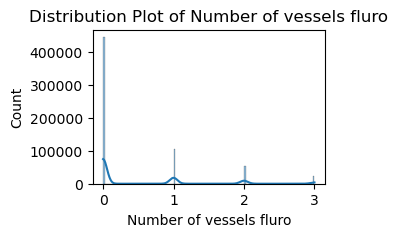

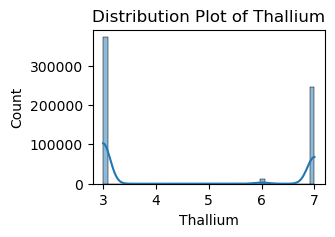

In [56]:
for col in X.columns:
    plt.figure(figsize=(3,2))
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution Plot of {col}')
    plt.show()

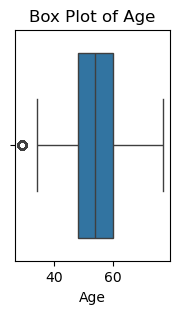

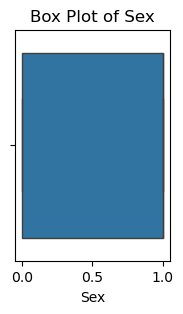

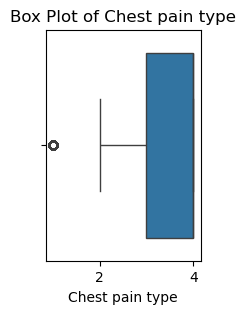

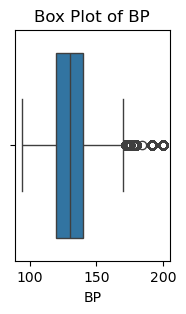

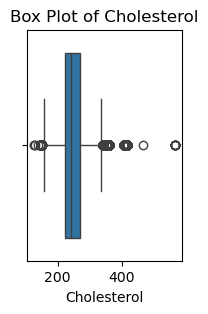

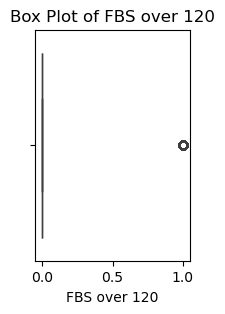

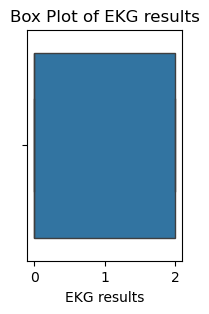

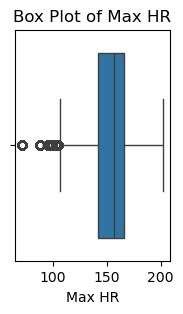

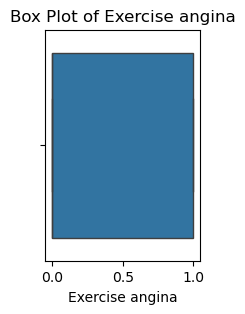

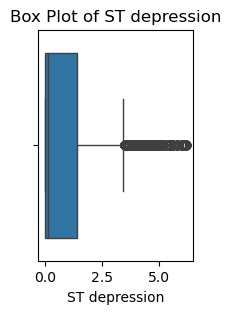

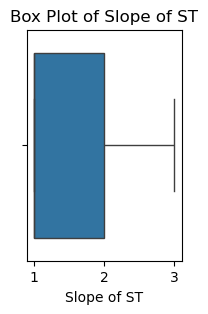

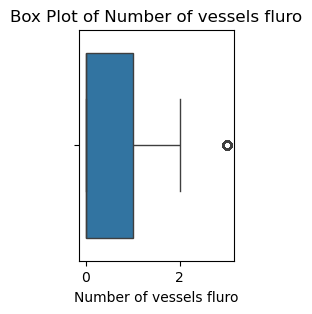

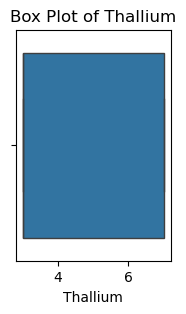

In [57]:
for col in X.columns:
    plt.figure(figsize=(2,3))
    sns.boxplot(x=X[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

<h5>calculating feature importance</h5>

In [58]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X, Y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                    Feature  Importance
12                 Thallium    0.183319
2           Chest pain type    0.138632
7                    Max HR    0.135659
4               Cholesterol    0.087085
11  Number of vessels fluro    0.078797
0                       Age    0.076309
9             ST depression    0.073200
8           Exercise angina    0.067905
3                        BP    0.060924
10              Slope of ST    0.055831
1                       Sex    0.026303
6               EKG results    0.010934
5              FBS over 120    0.005102


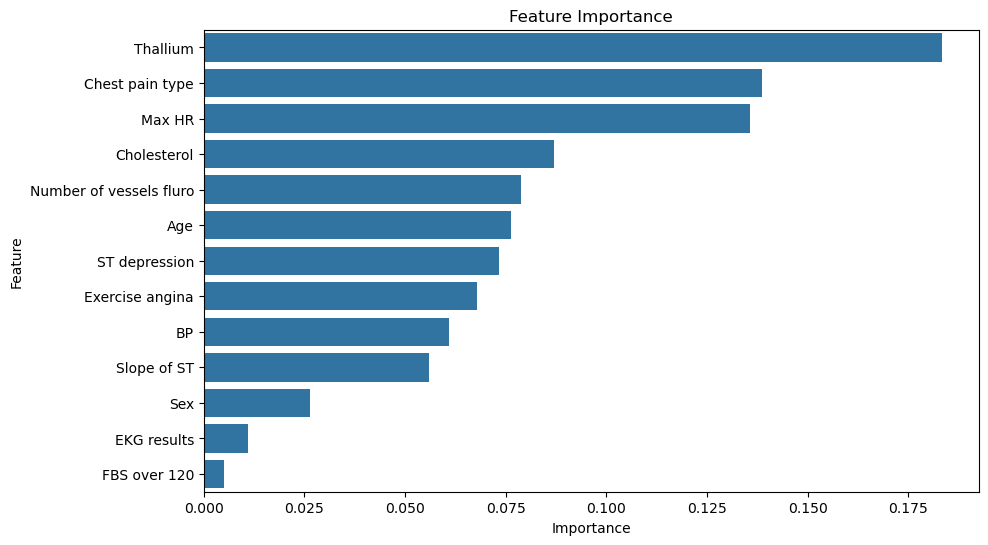

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

<p>We began the exploratory data analysis (EDA) by separating the dataset into features (`X`) and target (`y`) after converting the target column (`Heart Disease`) into numerical form using binary encoding. Since all variables were already in numeric format (`int64` and `float64`), no categorical encoding was required. Correlation analysis was then performed to understand the relationship between each feature and the target variable. The results showed that features such as **Thallium**, **Chest pain type**, **Exercise angina**, **Number of vessels fluro**, **ST depression**, and **Max HR** had strong relationships with heart disease prediction, while features like **FBS over 120** and **EKG results** exhibited very weak correlations. The `id` column showed almost zero correlation and was identified as a non-informative feature suitable for removal.

To further analyze feature behavior, distribution plots and box plots were generated for all variables. These visualizations helped identify the spread of the data, skewness patterns, and potential outliers in several medical attributes such as cholesterol and ST depression. A Random Forest model was then used to compute feature importance scores, providing a more robust understanding of predictive relevance beyond simple linear correlation. The feature importance analysis confirmed that **Thallium**, **Chest pain type**, and **Max HR** were among the most influential predictors, while **FBS over 120** and **EKG results** contributed minimally to prediction performance. Interestingly, some features such as **Cholesterol** showed relatively low linear correlation but higher feature importance, indicating the presence of nonlinear relationships within the dataset. These analyses established a strong foundation for proceeding toward model training and validation.
</p>

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

<p>Scaling the data and using logistic regression</p>

In [61]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [62]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [63]:
y_pred = lr.predict(X_val_scaled)

In [64]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.8846825396825397


In [65]:
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [66]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)
print(cm)

[[62988  6521]
 [ 8009 48482]]


In [67]:
from sklearn.metrics import roc_auc_score
y_prob = lr.predict_proba(X_val_scaled)[:,1]
roc = roc_auc_score(y_val, y_prob)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.951546958953206


<b><p>After preprocessing and exploratory data analysis, the dataset was divided into training and validation sets using a stratified train-test split to preserve the class distribution of the target variable. Since Logistic Regression is sensitive to differences in feature scales, standardization was performed using StandardScaler. The scaler was fitted only on the training data and then applied to both the training and validation sets to avoid data leakage. A Logistic Regression model was then trained as the baseline classification model for predicting heart disease.

The baseline model produced strong performance across multiple evaluation metrics. The model achieved an accuracy of approximately 88.47%, indicating high overall predictive capability. The classification report showed balanced precision, recall, and F1-scores for both classes, with values close to 0.88–0.90, suggesting stable classification performance without significant class bias. The confusion matrix further revealed that the model correctly identified a large number of both healthy and diseased patients, although the number of false negatives remained comparatively higher than false positives, which is an important consideration in medical prediction tasks. Additionally, the model achieved a ROC-AUC score of approximately 0.9515, demonstrating excellent discriminative ability between the two classes. These results established Logistic Regression as a strong baseline model before progressing toward more advanced ensemble methods such as Random Forest and gradient boosting algorithms.</p></b>

In [68]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [69]:
xgb_pred = xgb.predict(X_val)

In [70]:
print("Accuracy:", accuracy_score(y_val, xgb_pred))
print(classification_report(y_val, xgb_pred))

Accuracy: 0.888468253968254
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [71]:
xgb_prob = xgb.predict_proba(X_val)[:,1]
xgb_roc = roc_auc_score(y_val, xgb_prob)
print("ROC-AUC:", xgb_roc)

ROC-AUC: 0.9552486801988224


<h3>now some hyperparameter tuning</h3>

In [72]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)
print("Accuracy:", accuracy_score(y_val, xgb_pred))
print(classification_report(y_val, xgb_pred))
xgb_prob = xgb.predict_proba(X_val)[:,1]
xgb_roc = roc_auc_score(y_val, xgb_prob)
print("ROC-AUC:", xgb_roc)

Accuracy: 0.8897460317460317
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

ROC-AUC: 0.9559346042603684


<h3>now using stratified k fold ROC-AUC</h3>

In [73]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X,
    Y,
    cv=cv,
    scoring='roc_auc'
)

print(scores)

print("Mean ROC-AUC:", scores.mean())

[0.95549722 0.95453729 0.9552644  0.9547692  0.95563666]
Mean ROC-AUC: 0.9551409555089944


<H3>Final model training on full data</H3>

In [74]:
xgb.fit(X, Y)
test_pred = xgb.predict(test)

<h3>Submission file creation</h3>

In [75]:
# probabilities
test_pred = xgb.predict_proba(test)[:,1]

# create submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': test_pred
})

# save csv
submission.to_csv(
    'submission.csv',
    index=False
)

print(submission.head())

       id  Heart Disease
0  630000       0.950583
1  630001       0.009114
2  630002       0.983607
3  630003       0.006325
4  630004       0.186302


<p>Following the development of the baseline Logistic Regression model, an advanced ensemble learning approach using XGBoost was implemented to capture nonlinear feature interactions and improve predictive performance. The initial XGBoost model outperformed the baseline model, achieving an accuracy of approximately 88.85% and a ROC-AUC score of 0.9552, indicating stronger class discrimination capability. To further optimize performance, hyperparameter tuning was performed by adjusting parameters such as the number of estimators, tree depth, learning rate, subsampling ratio, and feature sampling ratio. The tuned XGBoost model demonstrated a slight but meaningful improvement, reaching an accuracy of approximately 88.97% and a ROC-AUC score of 0.9559. The model also maintained balanced precision, recall, and F1-scores across both target classes, indicating stable and generalized predictive behavior.

To validate the robustness of the tuned model, Stratified K-Fold Cross Validation was performed using five folds while preserving the target class distribution in each split. The cross-validation ROC-AUC scores remained highly consistent across all folds, with a mean ROC-AUC of approximately 0.9551, confirming strong model stability and low variance. The low fluctuation between folds indicated minimal overfitting and strong generalization capability on unseen data. Finally, the optimized XGBoost model was trained on the complete training dataset and used to generate prediction probabilities for the test dataset.</p>